# Tubes 1 IF3170 Pembelajaran Mesin
Puji syukur kehadirat Tuhan Yang Maha Kuasa karena berkat kehendak-Nya lah kita bisa menyelesaikan tubes ini. Tadinya mau dikebut pada malam 16 Maret 2026, eh nggak taunya malah di-extend. Terima kasih kakak-kakak asisten.

## 0. Import Library dan Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from ffnn import FFNN

SEED = 42
np.random.seed(SEED)

In [2]:
df = pd.read_csv('../data/datasetml_2026.csv')

## 1. Exploratory Data Analysis (EDA)
NB: beberapa diambil dari notebook praktikum 1

### 1.1. Gambaran Umum

In [3]:
df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      10000 non-null  float64
 1   backlogs                  10000 non-null  int64  
 2   college_tier              10000 non-null  object 
 3   country                   10000 non-null  object 
 4   university_ranking_band   10000 non-null  object 
 5   internship_count          10000 non-null  int64  
 6   aptitude_score            10000 non-null  float64
 7   communication_score       10000 non-null  float64
 8   specialization            10000 non-null  object 
 9   industry                  10000 non-null  object 
 10  internship_quality_score  10000 non-null  float64
 11  placement_status          10000 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 937.6+ KB


In [5]:
df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


In [14]:
# Cek missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


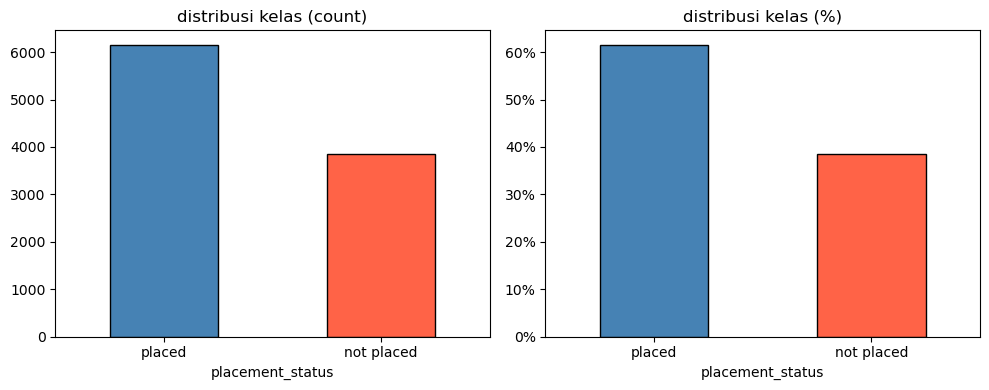


Imbalance ratio (majority/minority): 1.60


In [20]:
# Distribusi kelas target
print(df['placement_status'].value_counts())
print(df['placement_status'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['placement_status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('distribusi kelas (count)')
axes[0].set_xticklabels(['placed', 'not placed'], rotation=0)

df['placement_status'].value_counts(normalize=True).plot(kind='bar', ax=axes[1], color=['steelblue','tomato'], edgecolor='black')
axes[1].set_title('distribusi kelas (%)')
axes[1].set_xticklabels(['placed', 'not placed'], rotation=0)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

imbalance_ratio = df['placement_status'].value_counts().iloc[0] / df['placement_status'].value_counts().iloc[1]
print(f"\nImbalance ratio (majority/minority): {imbalance_ratio:.2f}")

---
## 2. Preprocessing

### 2.1. pisah kolom

In [27]:
target = 'placement_status'

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != target]

print('Numeric:', numeric_cols)
print('Categorical:', categorical_cols)

Numeric: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']


### 2.2. Encoding

In [28]:
le = LabelEncoder()
y_encoded = le.fit_transform(df[target])
n_classes = len(le.classes_)
print('Classes:', le.classes_)
print('n_classes:', n_classes)

X_raw = df.drop(columns=[target])

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

X_processed = preprocessor.fit_transform(X_raw)
print('Processed X shape:', X_processed.shape)

Classes: ['Not Placed' 'Placed']
n_classes: 2
Processed X shape: (10000, 28)


### 2.3. Split dataset jadi train val test

In [31]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.15, random_state=SEED, stratify=y_encoded
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85, random_state=SEED, stratify=y_trainval
)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

input_dim = X_train.shape[1]
output_dim = n_classes
print(f'Input dim: {input_dim}, Output dim: {output_dim}')

Train: (7000, 28), Val: (1500, 28), Test: (1500, 28)
Input dim: 28, Output dim: 2


---
## 3. Helper functions

In [35]:
def evaluate(model, X, y_true, label=''):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f'{label} akurasi: {acc:.4f}')
    return acc


def fit_with_val(model, X_tr, y_tr, X_v, y_v, batch_size=32, lr=0.01, epochs=100, verbose=False):
    from tensor import Tensor

    y_tr_prep = model._prepare_targets(y_tr)
    y_v_prep  = model._prepare_targets(y_v)

    history = {'train_loss': [], 'val_loss': []}
    n_samples = X_tr.shape[0]
    rng = np.random.default_rng(SEED)

    for epoch in range(epochs):
        #training
        indices = rng.permutation(n_samples)
        X_shuf  = X_tr[indices]
        y_shuf  = y_tr_prep[indices]
        batch_losses = []
        for start in range(0, n_samples, batch_size):
            Xb = X_shuf[start:start+batch_size]
            yb = y_shuf[start:start+batch_size]
            for p in model.parameters:
                p.zero_grad()
            preds = model.forward(Xb)
            loss  = model._compute_total_loss(yb, preds)
            model._backward(loss, yb, preds)
            model._step(lr)
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        history['train_loss'].append(train_loss)

        #validasi
        val_preds = model.forward(X_v)
        val_loss  = model._compute_total_loss(y_v_prep, val_preds).item()
        history['val_loss'].append(val_loss)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}  ' f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}')
    return history


def plot_loss_curves(histories: dict, title='Loss Curves'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for label, h in histories.items():
        axes[0].plot(h['train_loss'], label=label)
        axes[1].plot(h['val_loss'],   label=label)
    for ax, ttl in zip(axes, ['Training Loss', 'Validation Loss']):
        ax.set_title(ttl)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def make_model(layer_sizes, activations, loss='cce', init='uniform', seed=SEED, regularization=None, lambda_reg=0.01, backprop_mode='autograd', **kw):
    return FFNN(
        layer_sizes=layer_sizes,
        activations=activations,
        loss=loss,
        init=init,
        seed=seed,
        regularization=regularization,
        lambda_reg=lambda_reg,
        backprop_mode=backprop_mode,
        **kw
    )


epochs       = 50
batch_size   = 32
default_lr   = 0.01
default_arch = [input_dim, 64, 32, output_dim] 
default_act = ['relu', 'relu', 'softmax']

---
## 4. Eksperimen 1 (pengaruh depth & width)


Width-16: [28, 16, 16, 2]
Width-16 Train akurasi: 0.7601
Width-16 Val akurasi: 0.7480
Width-16 Test akurasi: 0.7500

Width-64: [28, 64, 64, 2]
Width-64 Train akurasi: 0.7506
Width-64 Val akurasi: 0.7180
Width-64 Test akurasi: 0.7480

Width-256: [28, 256, 256, 2]
Width-256 Train akurasi: 0.8671
Width-256 Val akurasi: 0.6880
Width-256 Test akurasi: 0.6900


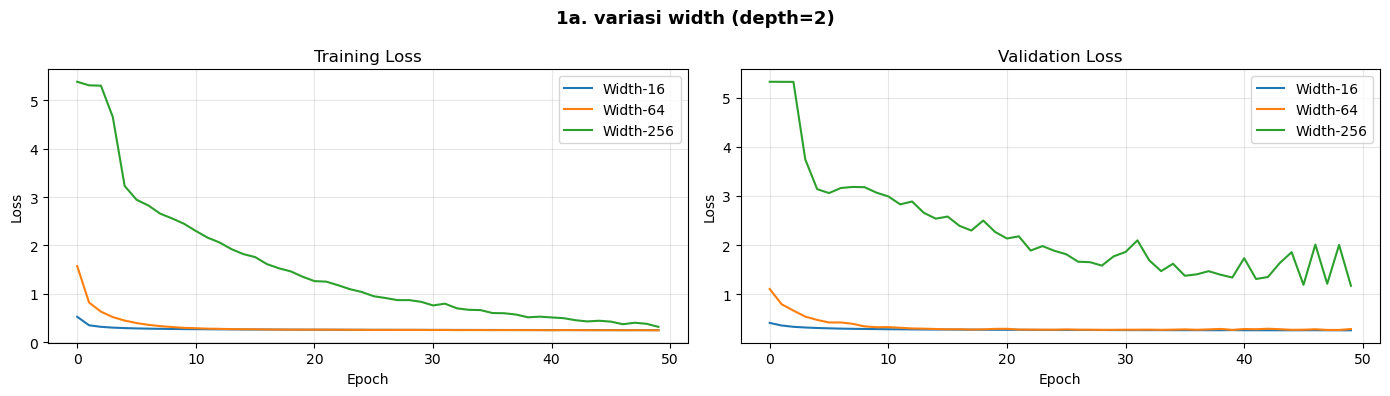

In [36]:
width_configs = { 'Width-16':  [input_dim, 16,  16,  output_dim], 'Width-64':  [input_dim, 64,  64,  output_dim], 'Width-256': [input_dim, 256, 256, output_dim]}
width_histories = {}
width_accs      = {}

for name, sizes in width_configs.items():
    print(f'\n{name}: {sizes}')
    m = make_model(sizes, ['relu', 'relu', 'softmax'])
    h = fit_with_val(m, X_train, y_train, X_val, y_val,
                     batch_size=batch_size, lr=default_lr, epochs=epochs)
    width_histories[name] = h
    width_accs[name] = {
        'train': evaluate(m, X_train, y_train, f'{name} Train'),
        'val':   evaluate(m, X_val,   y_val,   f'{name} Val'),
        'test':  evaluate(m, X_test,  y_test,  f'{name} Test'),
    }

plot_loss_curves(width_histories, title='1a. variasi width (depth=2)')

In [37]:
pd.DataFrame(width_accs).T

,train,val,test
Width-16,0.760143,0.748,0.750
Width-64,0.750571,0.718,0.748
Width-256,0.867143,0.688,0.690



Depth-1: [28, 64, 2]
Depth-1 Train akurasi: 0.7591
Depth-1 Val akurasi: 0.7413
Depth-1 Test akurasi: 0.7433

Depth-3: [28, 64, 64, 64, 2]
Depth-3 Train akurasi: 0.7043
Depth-3 Val akurasi: 0.6780
Depth-3 Test akurasi: 0.6833

Depth-5: [28, 64, 64, 64, 64, 64, 2]
Depth-5 Train akurasi: 0.6153
Depth-5 Val akurasi: 0.6153
Depth-5 Test akurasi: 0.6153


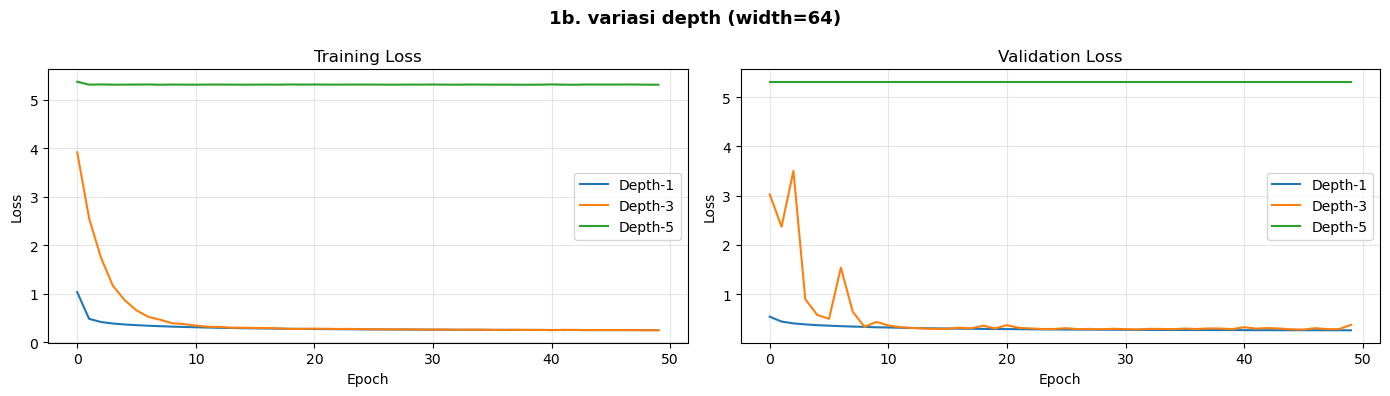

In [38]:
depth_configs = {
    'Depth-1': ([input_dim, 64, output_dim], ['relu', 'softmax']),
    'Depth-3': ([input_dim, 64, 64, 64, output_dim], ['relu', 'relu', 'relu', 'softmax']),
    'Depth-5': ([input_dim, 64,64,64,64,64,output_dim], ['relu','relu','relu','relu','relu','softmax']),
}

depth_histories = {}
depth_accs      = {}

for name, (sizes, acts) in depth_configs.items():
    print(f'\n{name}: {sizes}')
    m = make_model(sizes, acts)
    h = fit_with_val(m, X_train, y_train, X_val, y_val,
                     batch_size=batch_size, lr=default_lr, epochs=epochs)
    depth_histories[name] = h
    depth_accs[name] = {
        'train': evaluate(m, X_train, y_train, f'{name} Train'),
        'val':   evaluate(m, X_val,   y_val,   f'{name} Val'),
        'test':  evaluate(m, X_test,  y_test,  f'{name} Test'),
    }

plot_loss_curves(depth_histories, title='1b. variasi depth (width=64)')

### 4.2. Eksperimen 2 (perbandingna fungsi aktivasi)


Activation layer 0: linear | full acts: ['linear', 'relu', 'softmax']
act=linear Train akurasi: 0.7450
act=linear Val akurasi: 0.7360
act=linear Test akurasi: 0.7473

Activation layer 0: relu | full acts: ['relu', 'relu', 'softmax']
act=relu Train akurasi: 0.7359
act=relu Val akurasi: 0.7213
act=relu Test akurasi: 0.7260

Activation layer 0: sigmoid | full acts: ['sigmoid', 'relu', 'softmax']
act=sigmoid Train akurasi: 0.7593
act=sigmoid Val akurasi: 0.7513
act=sigmoid Test akurasi: 0.7487

Activation layer 0: tanh | full acts: ['tanh', 'relu', 'softmax']
act=tanh Train akurasi: 0.7561
act=tanh Val akurasi: 0.7333
act=tanh Test akurasi: 0.7433


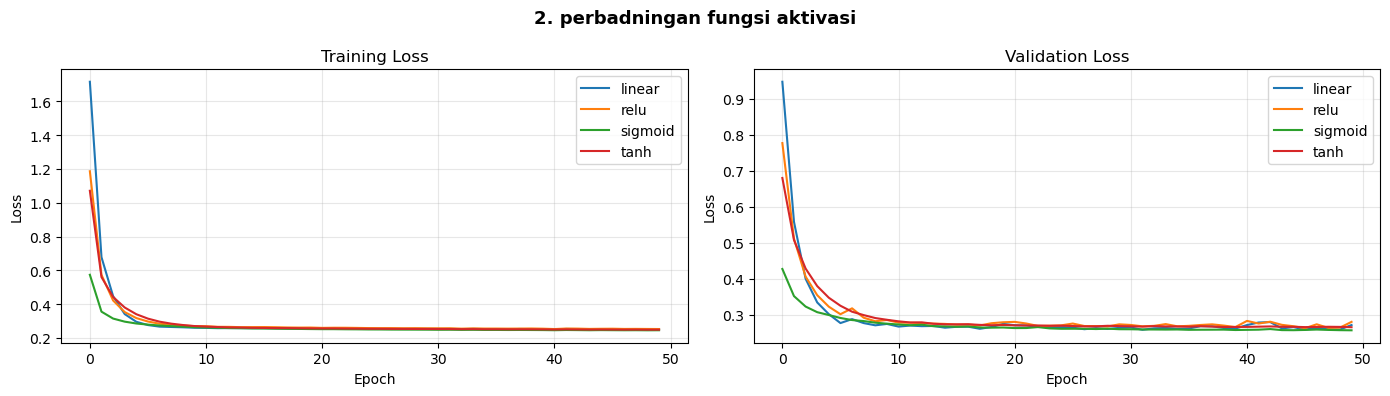

In [39]:
act_test_layer = 0
base_acts      = ['relu', 'relu', 'softmax']

activation_variants = ['linear', 'relu', 'sigmoid', 'tanh']
act_histories = {}
act_accs      = {}
act_models    = {}

for act in activation_variants:
    acts = base_acts.copy()
    acts[act_test_layer] = act
    print(f'\nActivation layer {act_test_layer}: {act} | full acts: {acts}')
    m = make_model(default_arch, acts)
    h = fit_with_val(m, X_train, y_train, X_val, y_val,
                     batch_size=batch_size, lr=default_lr, epochs=epochs)
    act_histories[act] = h
    act_models[act]    = m
    act_accs[act] = {
        'train': evaluate(m, X_train, y_train, f'act={act} Train'),
        'val':   evaluate(m, X_val,   y_val,   f'act={act} Val'),
        'test':  evaluate(m, X_test,  y_test,  f'act={act} Test'),
    }

plot_loss_curves(act_histories, title='2. perbadningan fungsi aktivasi')


fungsi aktivasi: linear
distribusi bobot (semua layer):


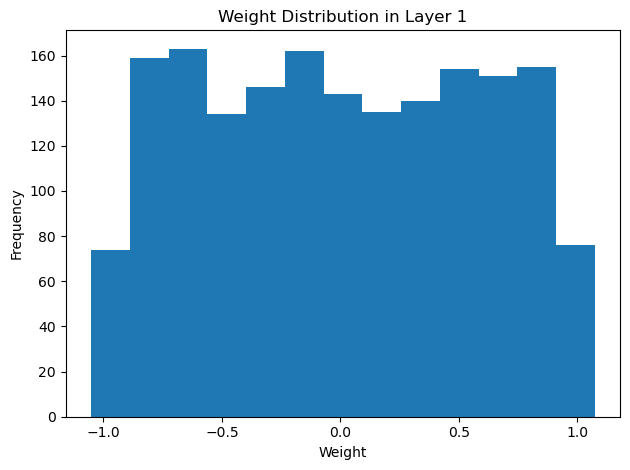

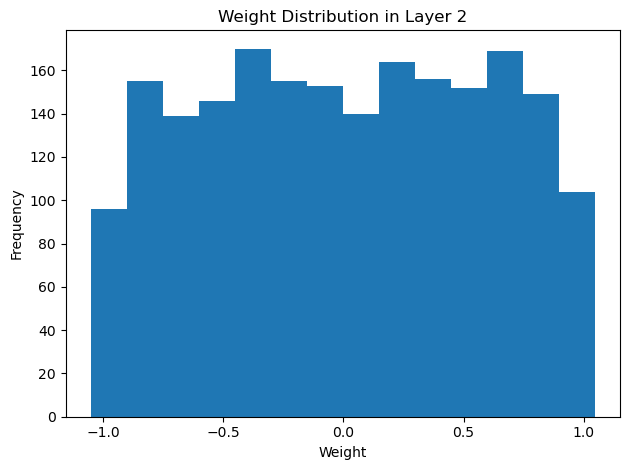

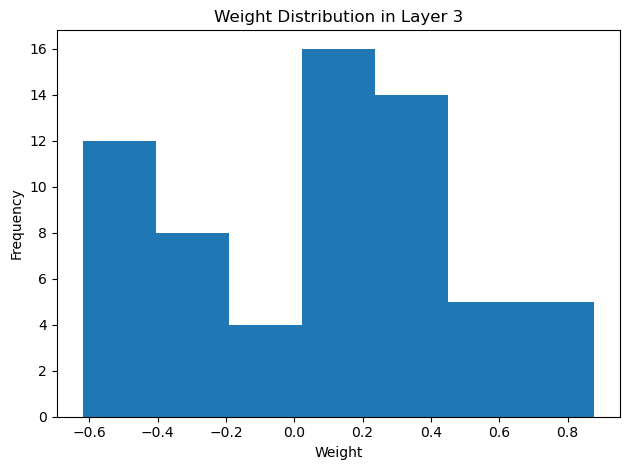

distribusi gradien (semua layer):


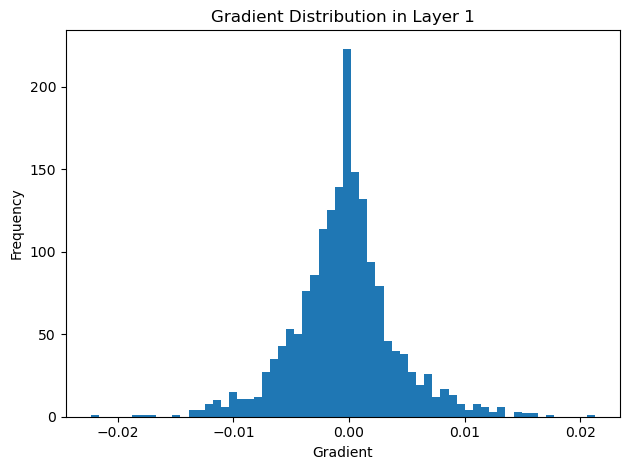

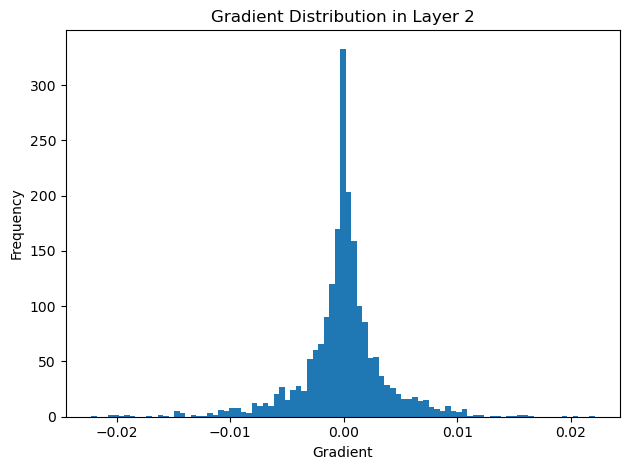

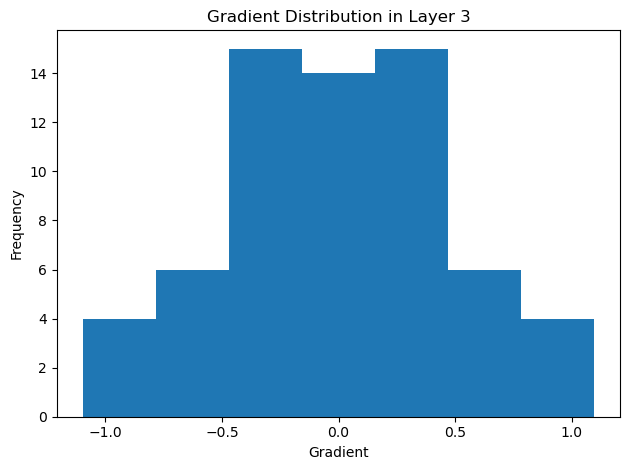


fungsi aktivasi: relu
distribusi bobot (semua layer):


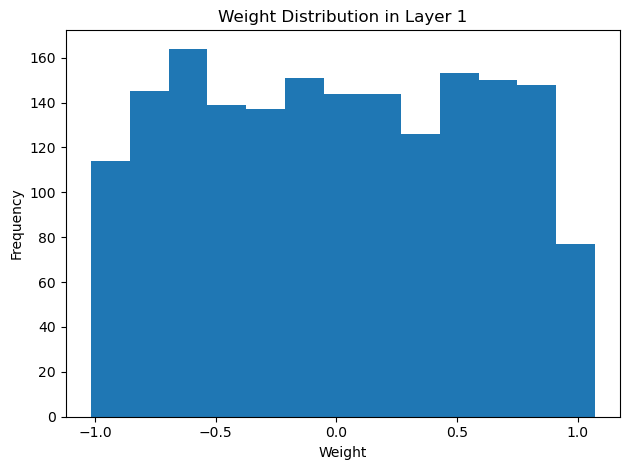

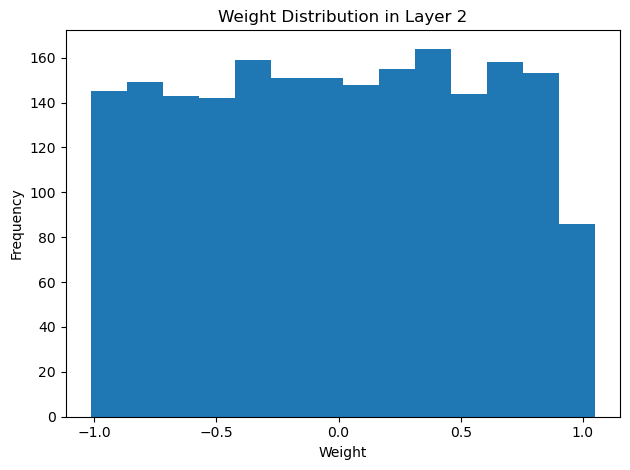

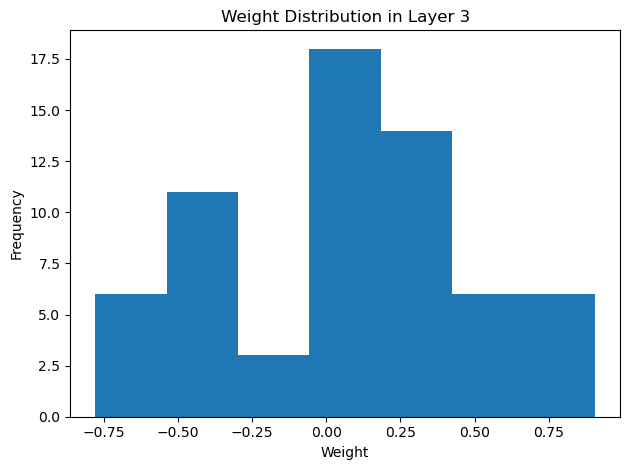

distribusi gradien (semua layer):


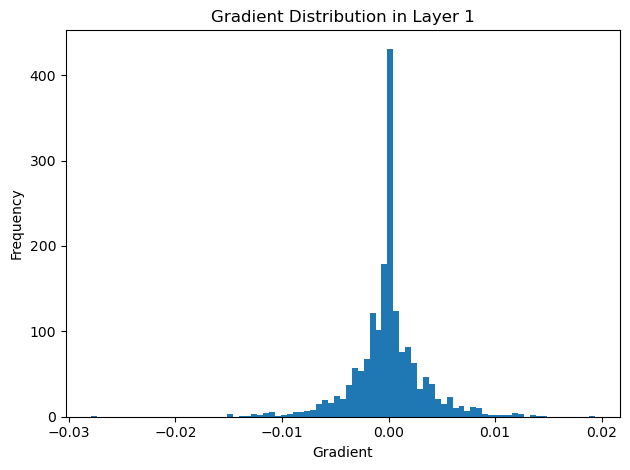

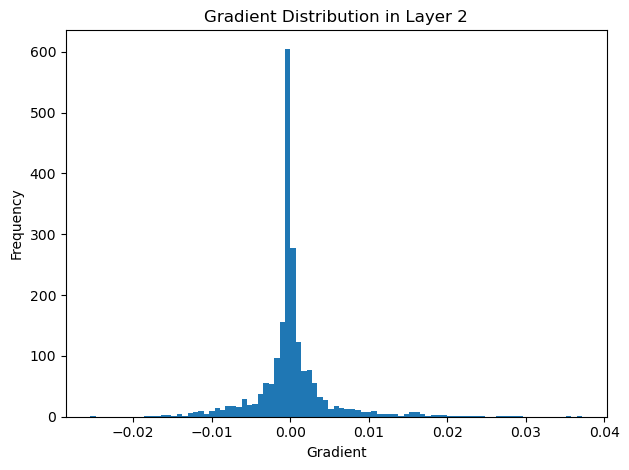

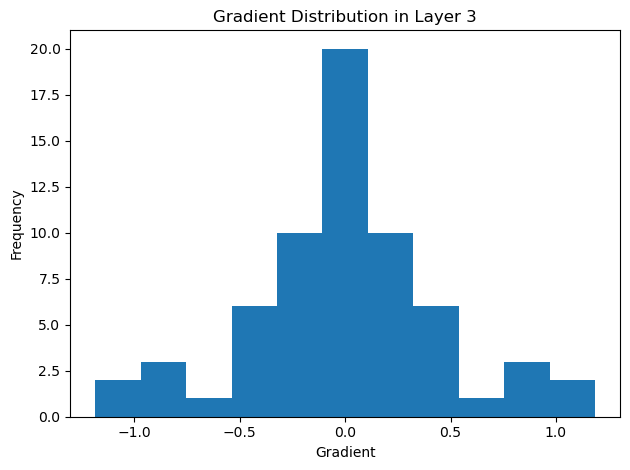


fungsi aktivasi: sigmoid
distribusi bobot (semua layer):


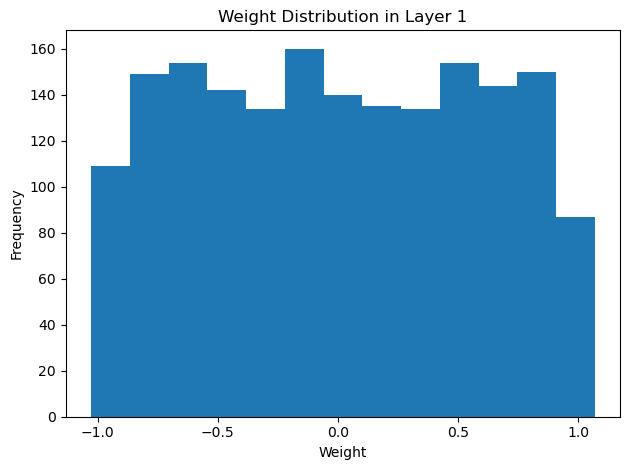

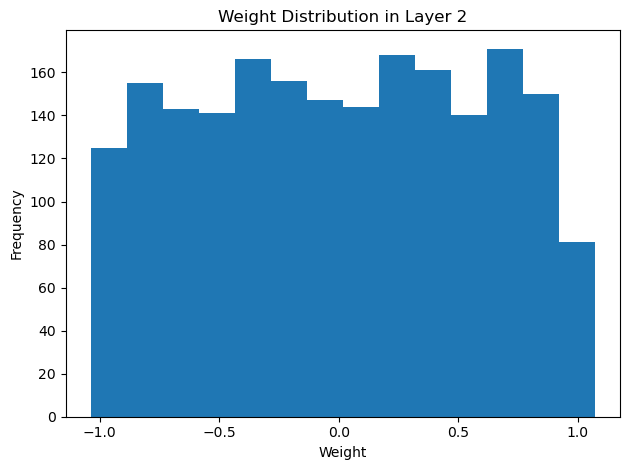

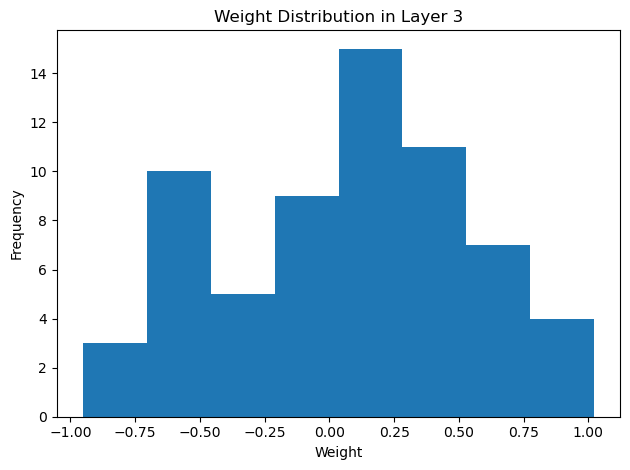

distribusi gradien (semua layer):


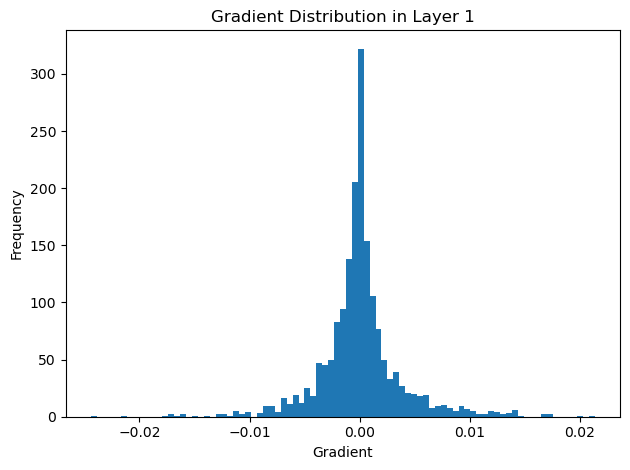

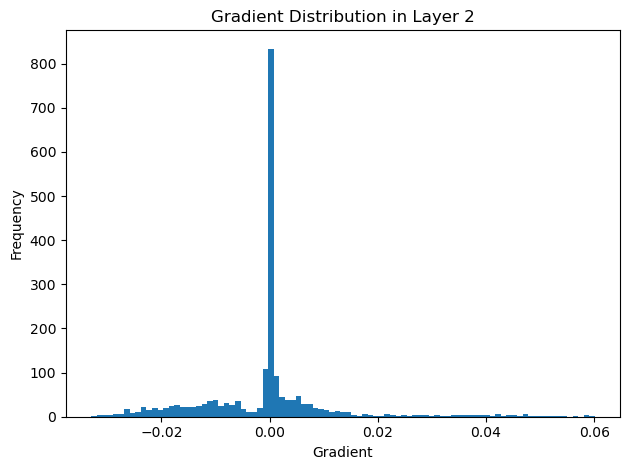

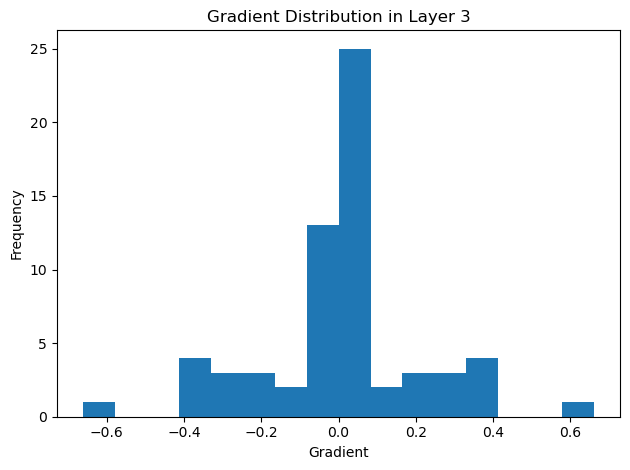


fungsi aktivasi: tanh
distribusi bobot (semua layer):


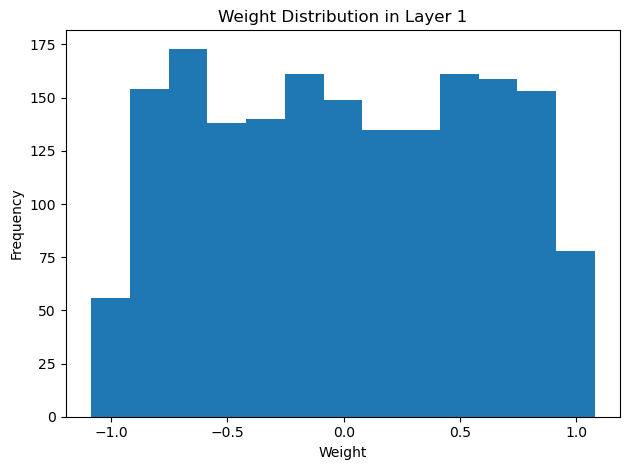

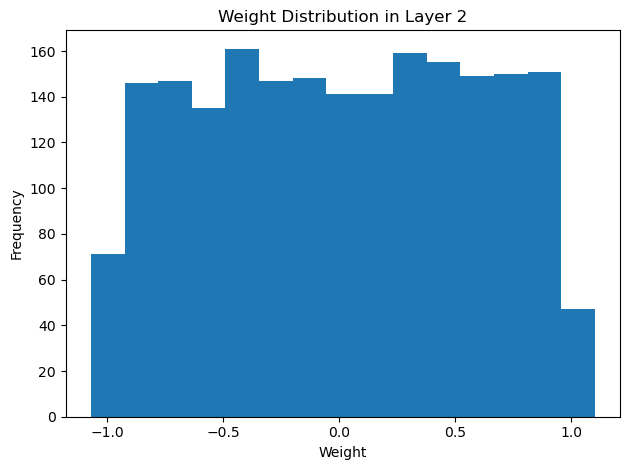

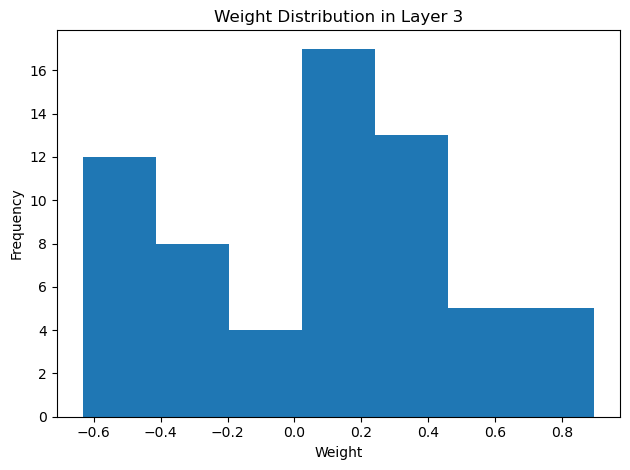

distribusi gradien (semua layer):


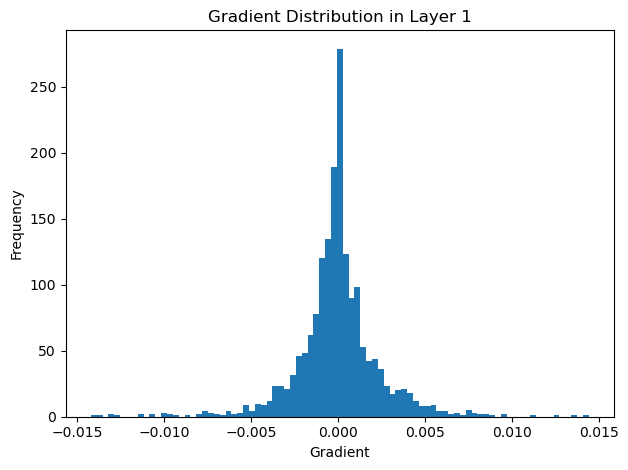

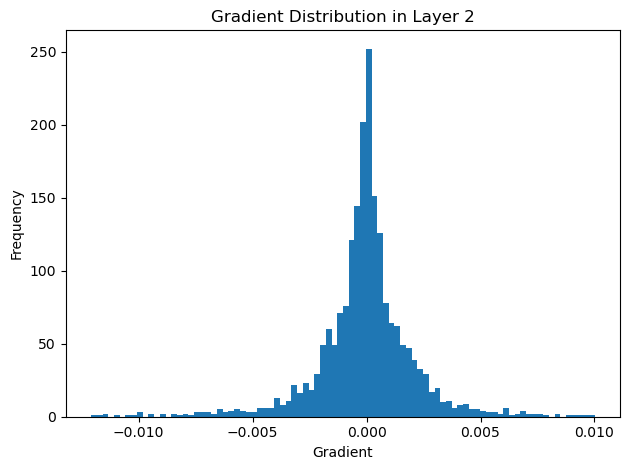

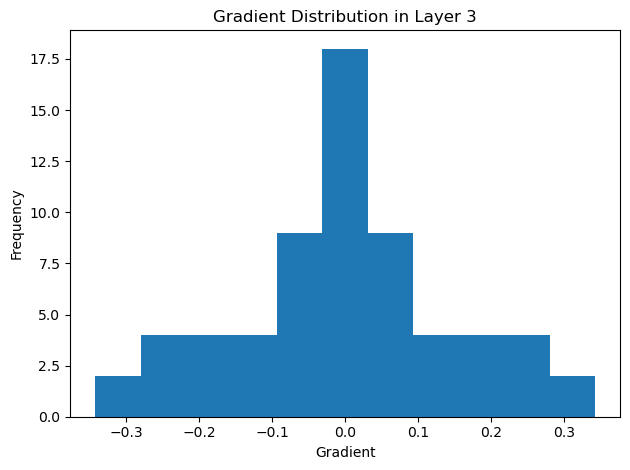

In [40]:
for act, m in act_models.items():
    print(f'\nfungsi aktivasi: {act}')
    print('distribusi bobot (semua layer):')
    m.plot_weight_distribution(list(range(len(m.layers))))
    print('distribusi gradien (semua layer):')
    m.plot_grad_distribution(list(range(len(m.layers))))

### 4.3. Eksperimen 3 (perbandingan learning rate)


lr=0.001
lr=0.001 Train akurasi: 0.7130
lr=0.001 Val akurasi: 0.6887
lr=0.001 Test akurasi: 0.7187

lr=0.01
lr=0.01 Train akurasi: 0.7359
lr=0.01 Val akurasi: 0.7213
lr=0.01 Test akurasi: 0.7260

lr=0.1
lr=0.1 Train akurasi: 0.7937
lr=0.1 Val akurasi: 0.7187
lr=0.1 Test akurasi: 0.7260


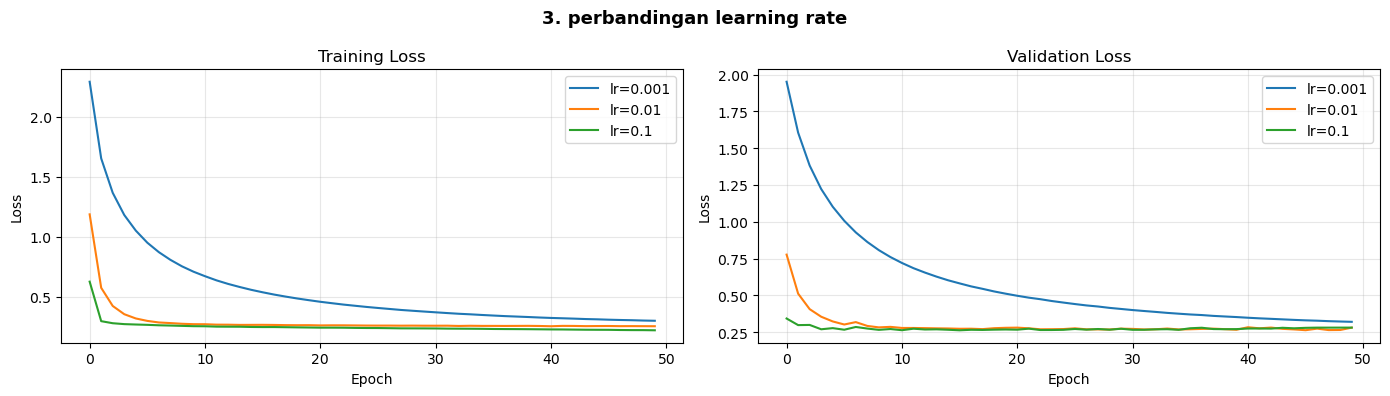

In [41]:
lr_variants = [0.001, 0.01, 0.1]
lr_histories = {}
lr_accs      = {}
lr_models    = {}

for lr in lr_variants:
    label = f'lr={lr}'
    print(f'\n{label}')
    m = make_model(default_arch, default_act)
    h = fit_with_val(m, X_train, y_train, X_val, y_val,
                     batch_size=batch_size, lr=lr, epochs=epochs)
    lr_histories[label] = h
    lr_models[label]    = m
    lr_accs[label] = {
        'train': evaluate(m, X_train, y_train, f'{label} Train'),
        'val':   evaluate(m, X_val,   y_val,   f'{label} Val'),
        'test':  evaluate(m, X_test,  y_test,  f'{label} Test'),
    }

plot_loss_curves(lr_histories, title='3. perbandingan learning rate')

In [42]:
pd.DataFrame(lr_accs).T

,train,val,test
lr=0.001,0.713000,0.688667,0.718667
lr=0.01,0.735857,0.721333,0.726000
lr=0.1,0.793714,0.718667,0.726000



lr=0.001


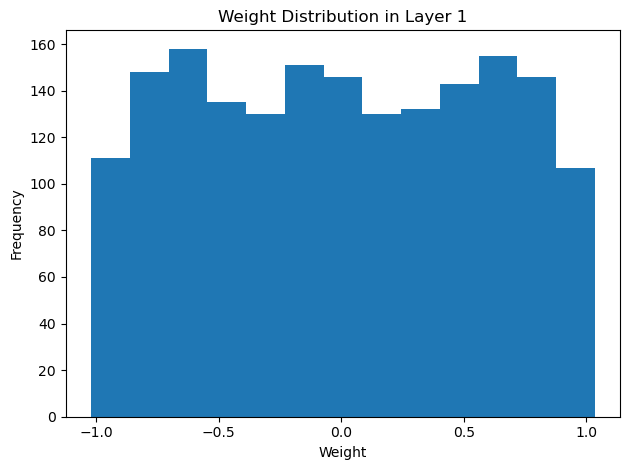

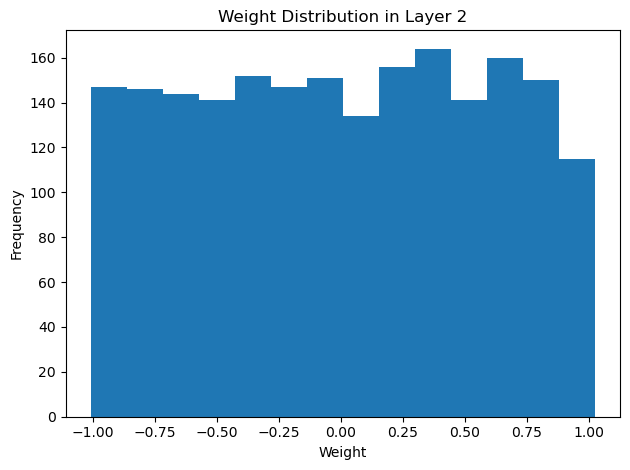

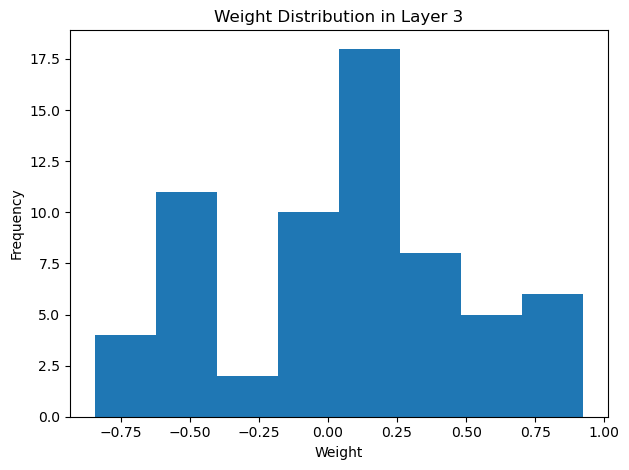

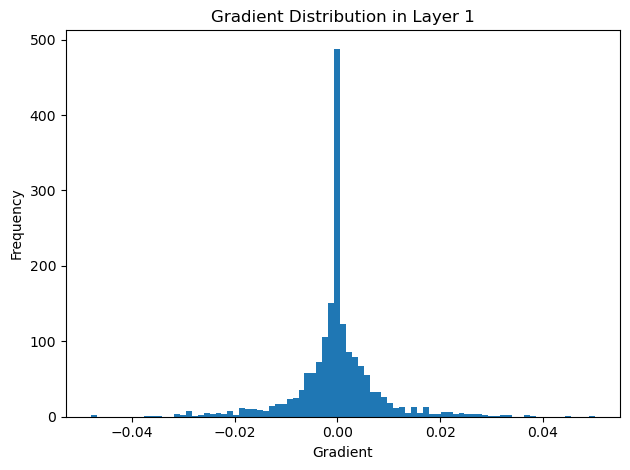

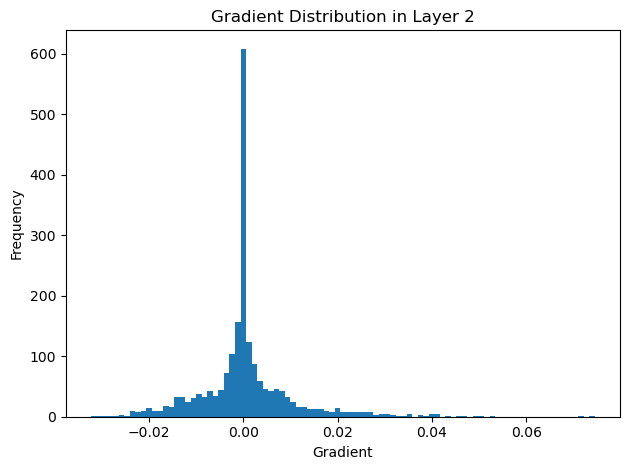

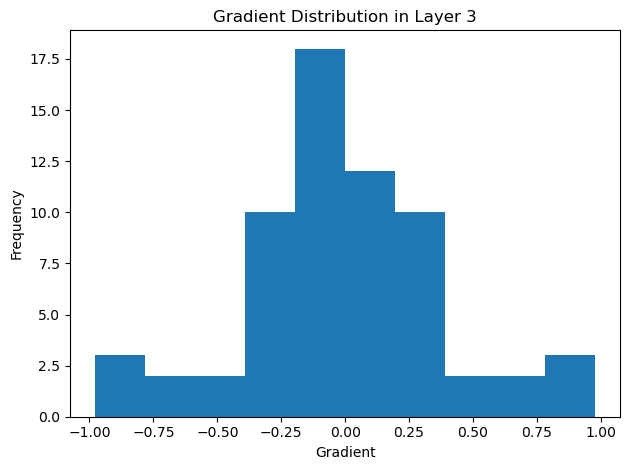


lr=0.01


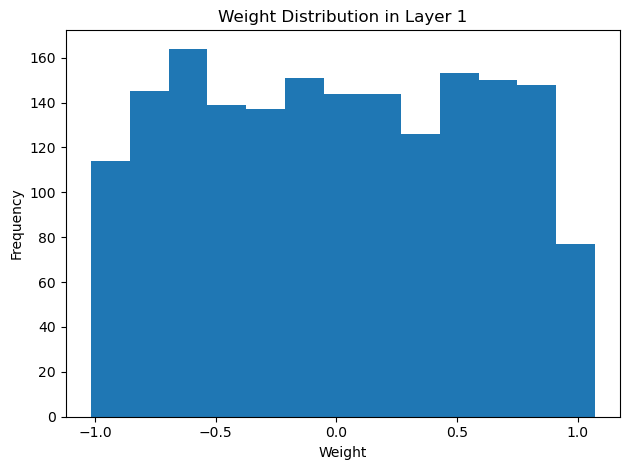

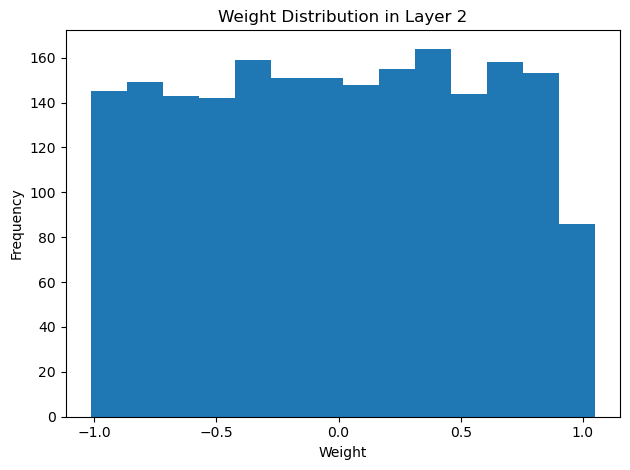

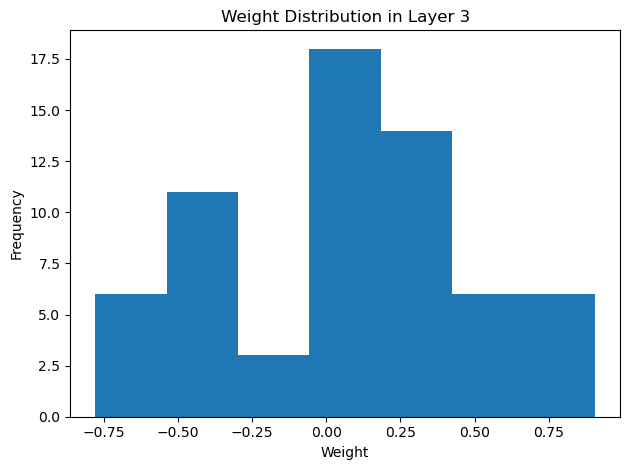

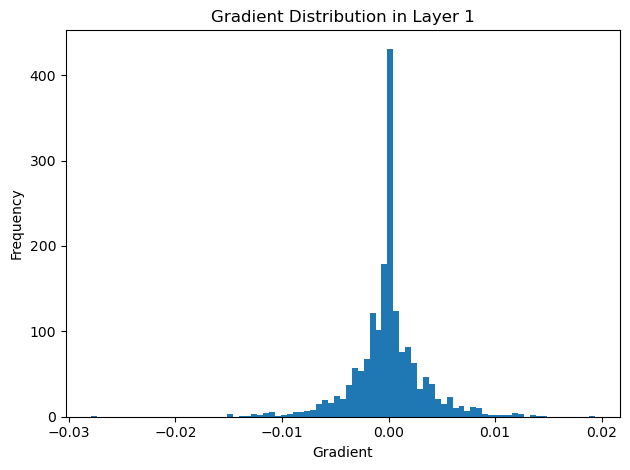

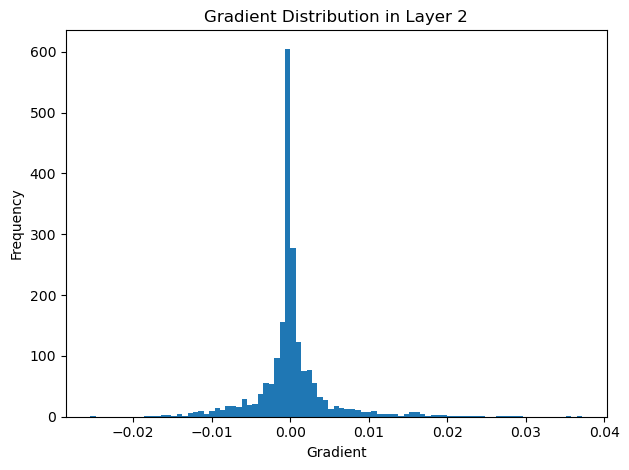

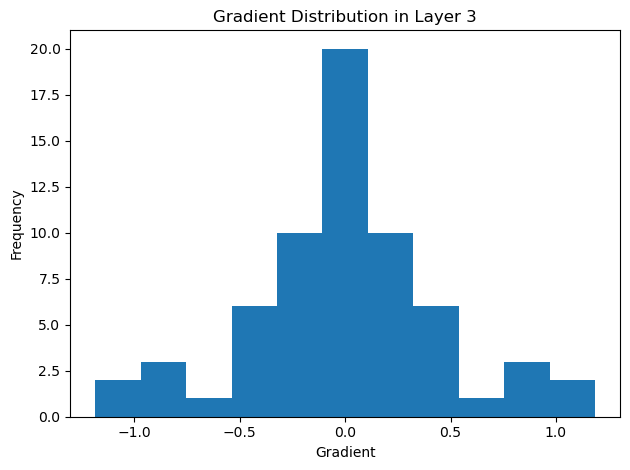


lr=0.1


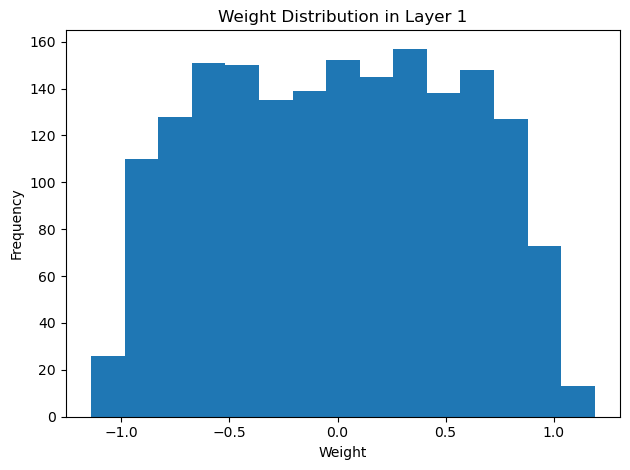

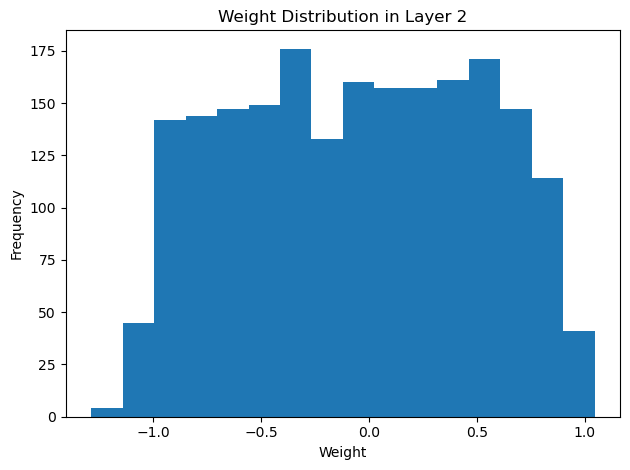

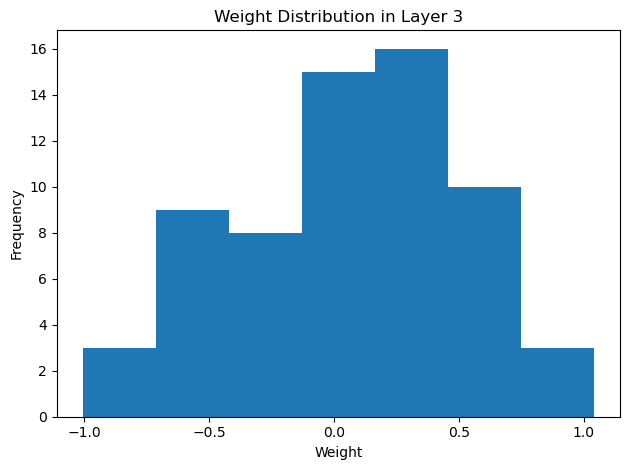

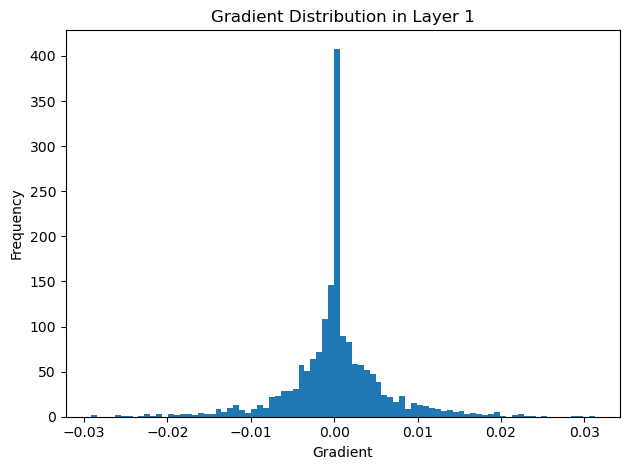

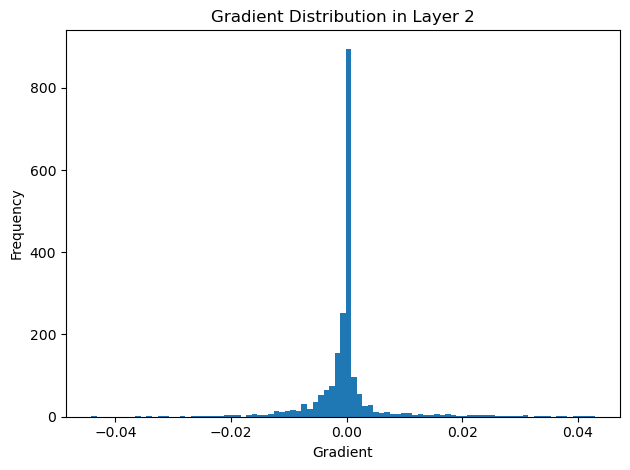

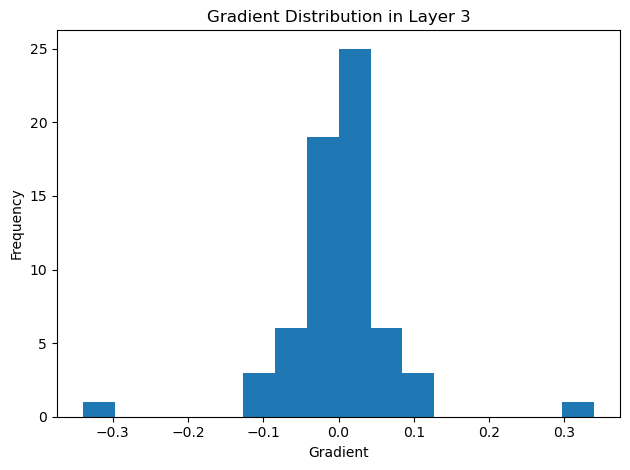

In [43]:
for label, m in lr_models.items():
    print(f'\n{label}')
    m.plot_weight_distribution(list(range(len(m.layers))))
    m.plot_grad_distribution(list(range(len(m.layers))))

### 4.4. Pengaruh regularisasi


normal
normal Train akurasi: 0.7359
normal Val akurasi: 0.7213
normal Test akurasi: 0.7260

L1 (λ=1e-3)
L1 (λ=1e-3) Train akurasi: 0.7520
L1 (λ=1e-3) Val akurasi: 0.7340
L1 (λ=1e-3) Test akurasi: 0.7500

L2 (λ=1e-3)
L2 (λ=1e-3) Train akurasi: 0.7543
L2 (λ=1e-3) Val akurasi: 0.7413
L2 (λ=1e-3) Test akurasi: 0.7473


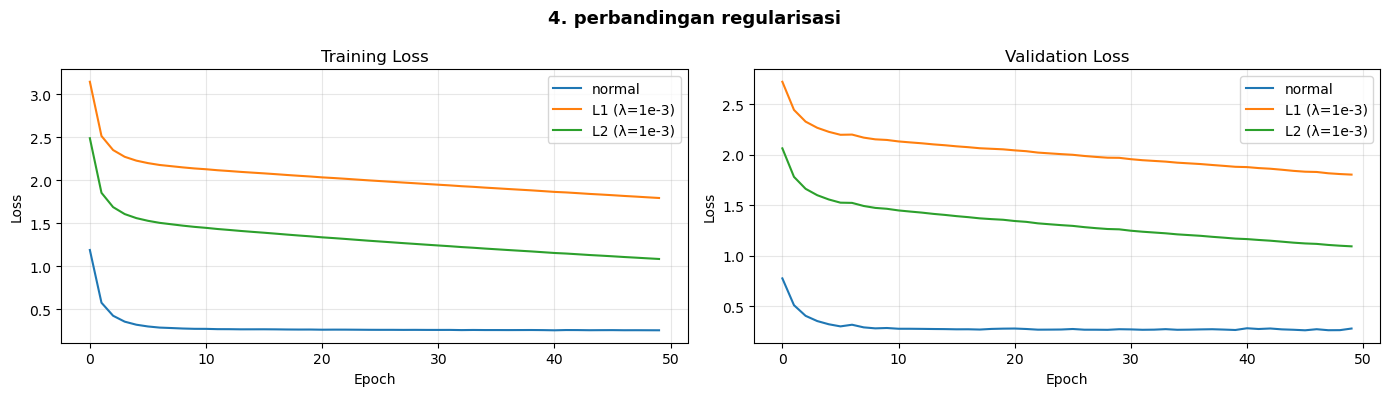

In [48]:
reg_configs = {
    'normal':    dict(regularization=None),
    'L1 (λ=1e-3)': dict(regularization='l1', lambda_reg=1e-3),
    'L2 (λ=1e-3)': dict(regularization='l2', lambda_reg=1e-3),
}

reg_histories = {}
reg_accs      = {}
reg_models    = {}

for name, kwargs in reg_configs.items():
    print(f'\n{name}')
    m = make_model(default_arch, default_act, **kwargs)
    h = fit_with_val(m, X_train, y_train, X_val, y_val,
                     batch_size=batch_size, lr=default_lr, epochs=epochs)
    reg_histories[name] = h
    reg_models[name]    = m
    reg_accs[name] = {
        'train': evaluate(m, X_train, y_train, f'{name} Train'),
        'val':   evaluate(m, X_val,   y_val,   f'{name} Val'),
        'test':  evaluate(m, X_test,  y_test,  f'{name} Test'),
    }

plot_loss_curves(reg_histories, title='4. perbandingan regularisasi')

In [47]:
pd.DataFrame(reg_accs).T

,train,val,test
normal,0.735857,0.721333,0.726



normal


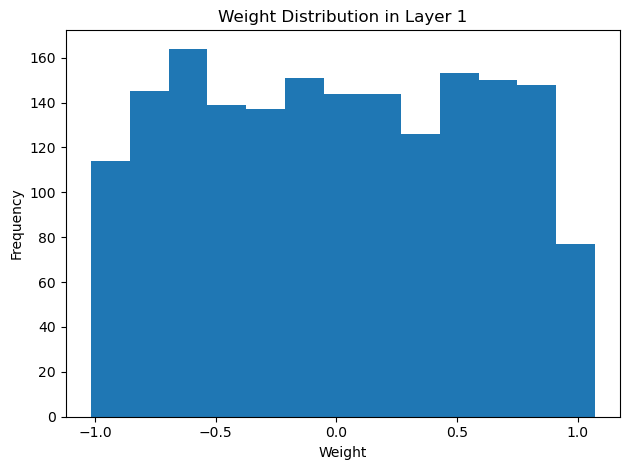

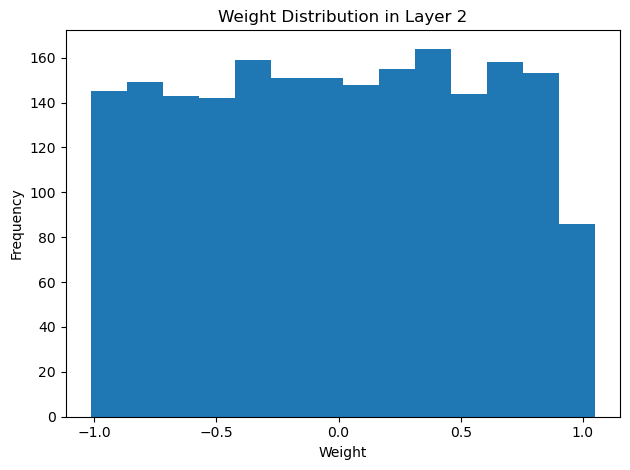

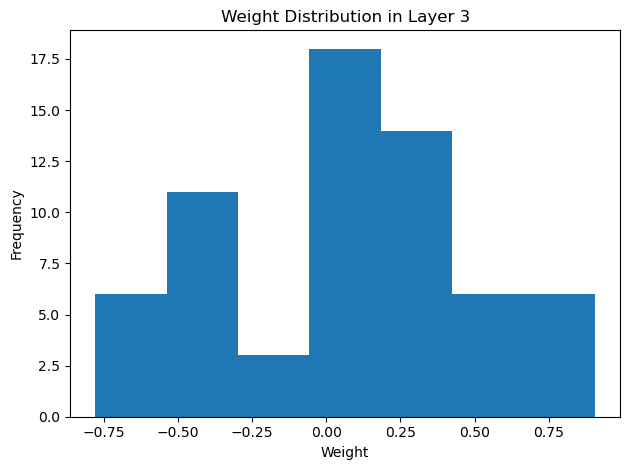

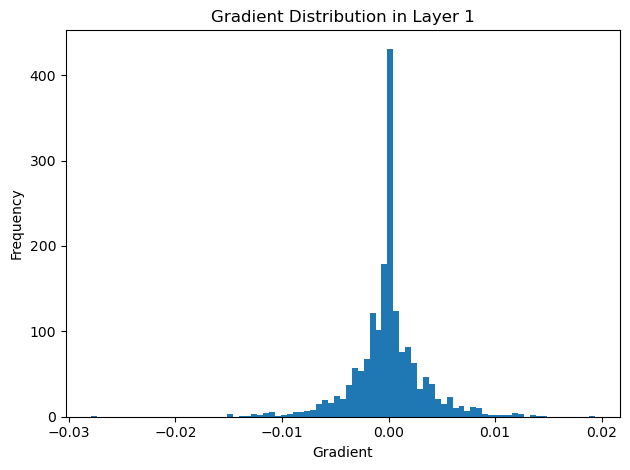

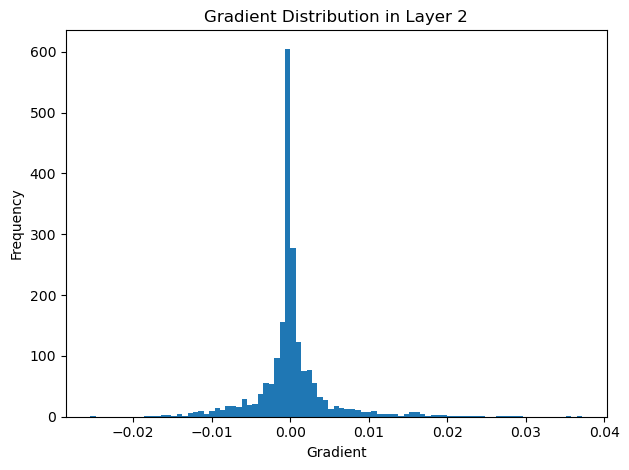

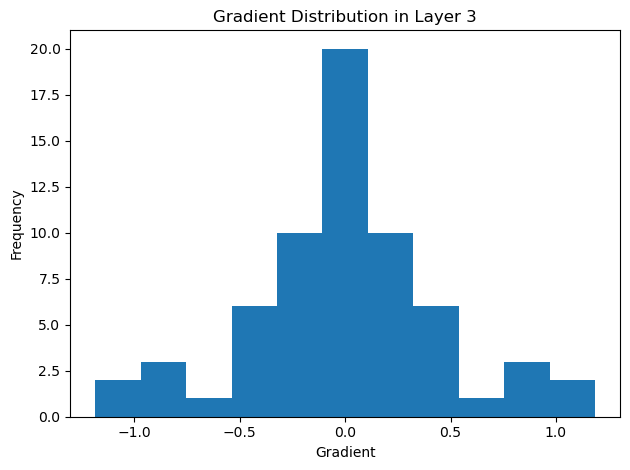


L1 (λ=1e-3)


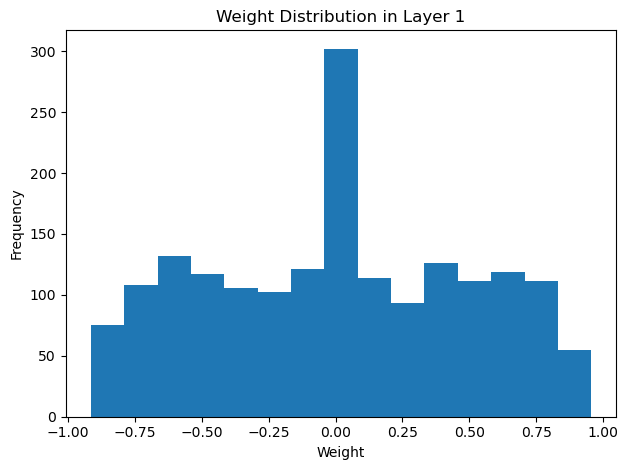

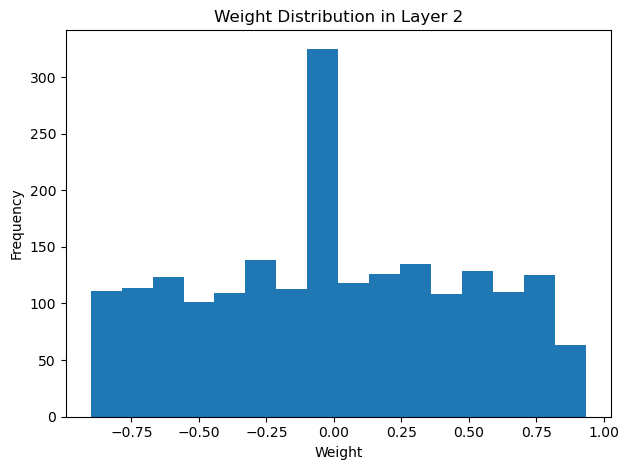

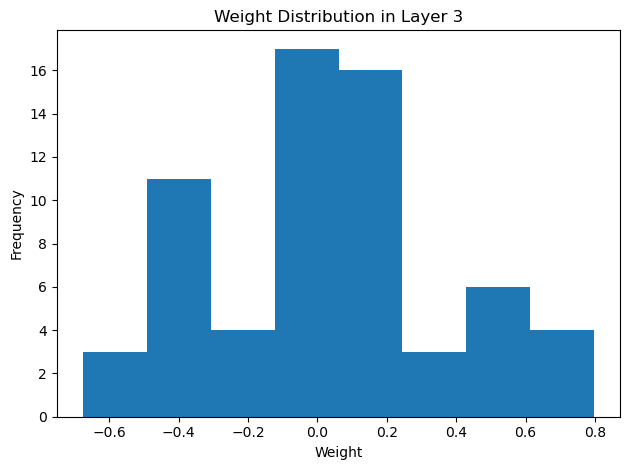

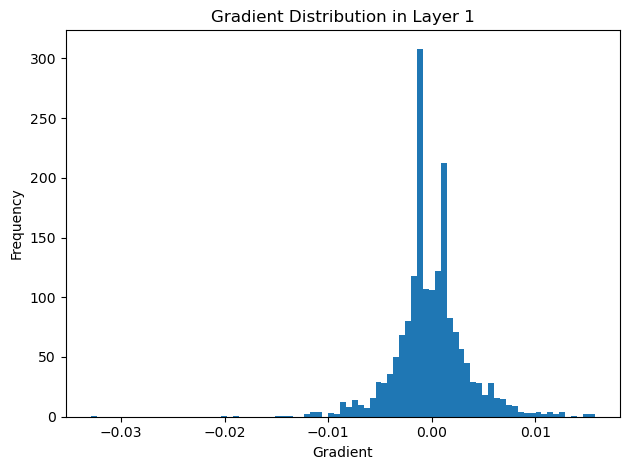

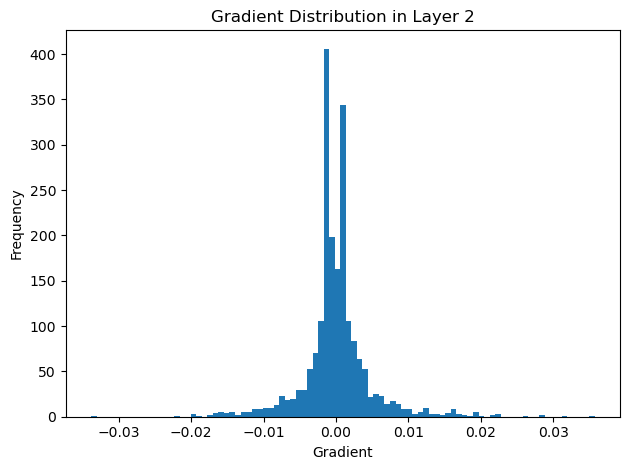

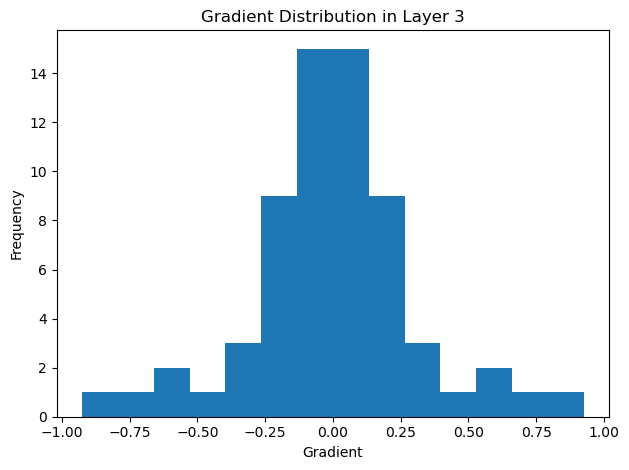


L2 (λ=1e-3)


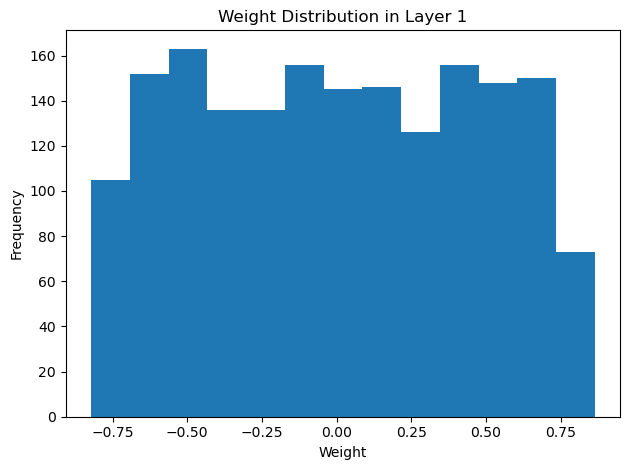

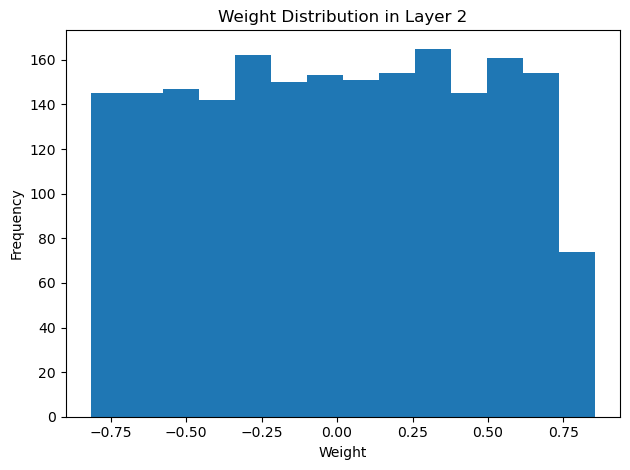

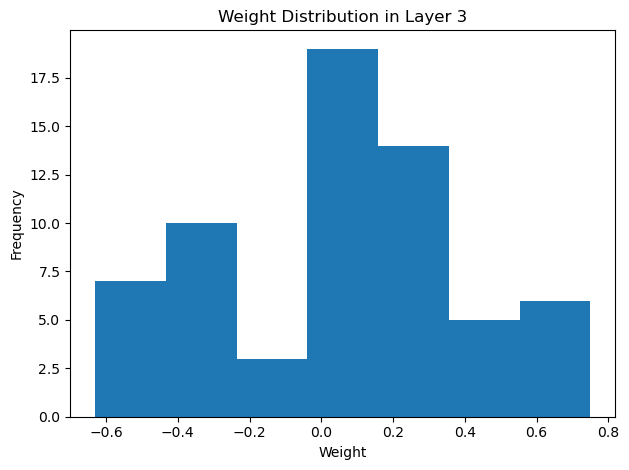

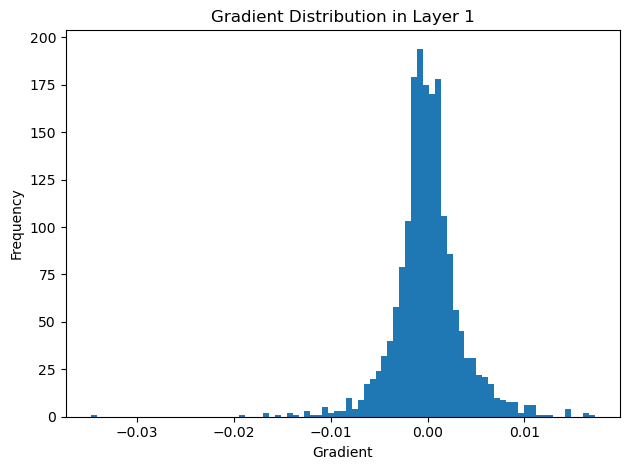

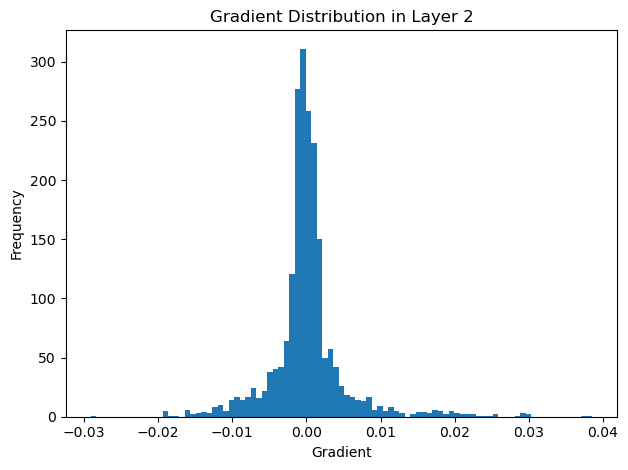

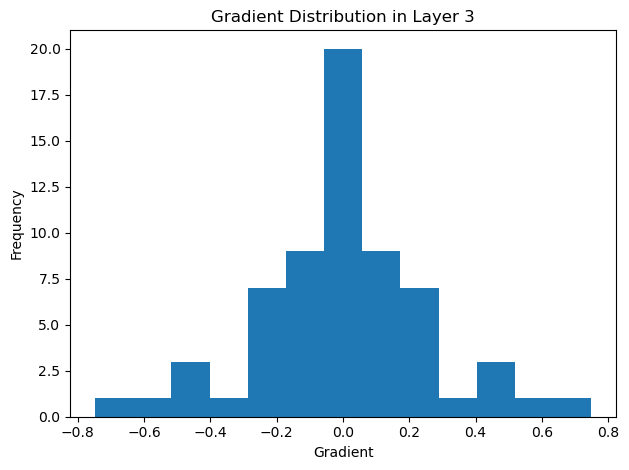

In [49]:
for name, m in reg_models.items():
    print(f'\n{name}')
    m.plot_weight_distribution(list(range(len(m.layers))))
    m.plot_grad_distribution(list(range(len(m.layers))))